In [3]:
# 导入库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
plt.rcParams['font.family'] = 'sans-serif'        # 第 1 行：指定族
plt.rcParams['font.sans-serif'] = ['SimHei']      # 第 2 行：给族放中文字体
plt.rcParams['axes.unicode_minus'] = False        # 第 3 行：修复负号

In [4]:
# 导入数据
df = pd.read_csv(r'D:\py-90-day\数据分析\data\house_sales.csv')

In [5]:
# 数据概览
print('总记录数:',len(df))
print('字段数量(列):',len(df.columns))


总记录数: 106118
字段数量(列): 12


In [ ]:
### 数据清洗

#删除无用的列
df.drop(columns='origin_url',inplace = True)

#检查是否有缺失值
df.isna().sum()
#删除缺失值
df.dropna(inplace=True)


In [7]:
#检查是否有重复值
df.duplicated().sum()
#删除重复数据
df.drop_duplicates(inplace=True)
# print(len(df))

In [ ]:
#面积的数据分析类型转换
df['area'] = df['area'].str.extract(r'(\d+\.?\d*)', expand=False).astype(float)
#售价的数据类型转换
df['price'] = df['price'].str.replace('万',' ').astype(float)
#朝向数据转换
df['toward'] = df['toward'].astype('category')
#单价的数据类型转换
df['unit'] = df['unit'].str.replace('元/㎡',' ').astype(float)
#年份的数据类型转换
df['year']=df['year'].str.replace('年建',' ').astype(int)

In [ ]:
###异常值的处理

#房屋面积的异常处理
df[(df['area']<600) & (df['area']>20)]

In [54]:
#房屋售价的异常处理(过高或过低)
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
low_price = Q1 - 1.5*IQR
high_price = Q3 + 1.5*IQR
df = df[(df['price']<high_price) & (df['price']>low_price)]

In [ ]:
# 新数据特征构造

#地区district
df['district']= df['address'].str.split('-').str[0]
#楼层的类型floor_type
df['floor_type'] = df['floor'].str.split('（').str[0]
#是否为直辖市zxs
def fun2(str2):
    if str2 in ['北京','上海','天津','重庆']:
        return  True
    else:
        return False 
df['zxs']=df['city'].apply(fun2)
#卧室的数量bedrooms
df['bedrooms'] = df['rooms'].str.split('室').str[0].astype(int)
#客厅的数量livingrooms
df['livingrooms'] = df['rooms'].str.extract(r'(\d+)厅').astype(int)
#楼龄buliding_age
df['building_age'] = 2025-df['year']
#价格的分段price_labels
df['price_labels'] = pd.cut(df['price'],bins = 4,labels = ['低价','中价','高价','豪华'])

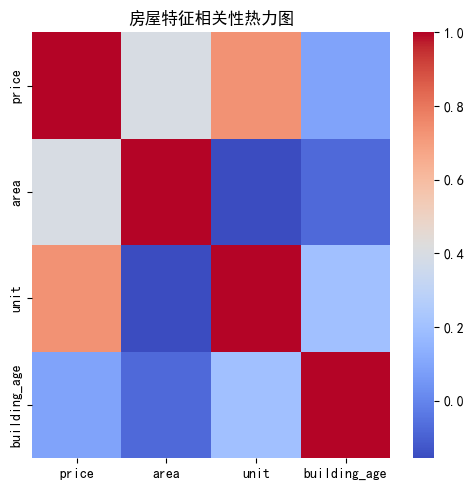

In [104]:
# 问题分析及可视化
# 选择数值型特征
a = df[['price', 'area', 'unit', 'building_age']].corr()

# 对房价影响最大的因素的排序
a['price'].sort_values(ascending=False)[1:]

# 相关性的热力图
plt.figure(figsize=(5, 5))
sns.heatmap(a, cmap='coolwarm')
plt.title('房屋特征相关性热力图')
plt.tight_layout()

In [102]:
df.sample(10)  #随机抽查


,city,address,area,floor,name,price,province,rooms,toward,unit,year,district,floor_type,zxs,bedrooms,livingrooms,building_age,price_labels
78954,万宁,老城-经济开发区生态软件园内,106.00,高层,融创美伦熙语,108.4,海南,3室2厅,南向,10226.0,2019,老城,高层,False,3,2,6,中价
22460,丰县,金龙湖-金山福地徐海路与汉源大道交叉口西南侧,104.00,低层,金山福地,118.0,江苏,3室2厅,南向,11346.0,2013,金龙湖,低层,False,3,2,12,中价
46310,海盐,嘉兴高铁南站-国际商务区-嘉兴高铁南站-白鹤郡,100.00,中层,白鹤郡,92.0,浙江,3室2厅,南北向,9200.0,2018,嘉兴高铁南站,中层,False,3,2,7,中价
38724,连云港,西小区-盐河路以西、新建路以北,93.50,低层,一方山水,99.0,江苏,2室2厅,南北向,10588.0,2012,西小区,低层,False,2,2,13,中价
2814,长沙,普瑞大道-银星路999号(银星路与黄金大道交汇处东南角,95.00,中层,澳海澜庭,57.0,湖南,3室2厅,南北向,6000.0,2018,普瑞大道,中层,False,3,2,7,低价
95162,清远,佛冈-清远市佛冈县石角镇振兴南路33号,108.00,中层,佛冈华府,72.5,广东,3室2厅,东南向,6713.0,2014,佛冈,中层,False,3,2,11,低价
91296,姜堰,泰州老街-海陵区迎春东路东延线与兴泰南路交汇处,91.00,高层,鹏欣领誉,115.0,江苏,2室2厅,南向,12637.0,2012,泰州老街,高层,False,2,2,13,中价
17516,安溪,桥南片区-百捷中央名门桥南片区中轴线东南侧,115.25,高层,百捷中央名门,155.0,福建,3室2厅,南向,13449.0,2008,桥南片区,高层,False,3,2,17,中价
45166,海盐,城区-海盐-城区-荣安·海上明月,100.00,中层,荣安·海上明月,90.0,浙江,3室2厅,南北向,9000.0,2017,城区,中层,False,3,2,8,中价
7164,句容,华阳街道-河滨南路(与东昌路交汇处),110.00,中层,御东国际,81.0,江苏,3室2厅,南北向,7364.0,2019,华阳街道,中层,False,3,2,6,低价
